# HadISD Tutorial Seven - Integration of Parquet Data with PyEarthTools

> **NOTE**
> Before beginning this tutorial, you should first read [HadISD Tutorial One - Introduction to Station Data](./HadISD-One-Introduction.ipynb) and ensure you complete the tutorials in order

This tutorial is similar to tutorial five, in that it creates a data accessor for station data. However, it is (a) much faster, and (b) differs in that it returns data as pandas dataframe loaded from parquet files. This shows the effectiveness of working with the right data formats and structures, as well as showing how PyEarthTools can flexibly work with a variety of technologies.

This tutorial demonstrates how to create a data accessor for the station data which will integrate with PyEarthTools pipelines. In due course, a similar implementation will be put into the relevant site archive packages for people working in supported facilities, but this demonstrates how you can easily connect your own station data archive into the framework from first principles. Working with custom station datasets is relatively common (e.g. hydrology-specific data sets, different temporal resolutions, region-specific datasets, data sources not included in the global data sharing etc) and so seeing the entire process is of value.

This tutorial will show how to:

 - Create a data accessor on-the-fly in the notebook
 - Work with parquet data
 - Access and plot weather station data
 - Access that data alongside gridded data, and plot the overlay


In [1]:
import pyearthtools.data
import pyearthtools.pipeline
from pyearthtools.data import Petdt

import pandas as pd
import pyarrow.compute as pc
import pyarrow.dataset as pds
import pandas as pd
import datetime

import numpy as np

import xarray as xr

from pathlib import Path
WBERA5_DIR = Path('/g/data/kd24/data') / 'wbera5' / 'by_decade' 
STATION_PARQUET = Path("/scratch/nf33/data/hadisd/parquet")

from mpl_toolkits.basemap import Basemap

In [2]:
from pyearthtools.data.indexes import Index, decorators
from pyearthtools.data.transforms import Transform, TransformCollection

class ISD(Index):
    @property
    def _desc_(self):
        return {
            "singleline": "Hadley Integrated Surface Database",
            "range": "1930 - 2025",
            "Documentation": "https://www.metoffice.gov.uk/hadobs/hadisd/",
        }

    def __init__(
        self,
        disk_location,
        *,        
        transforms: Transform | TransformCollection | None = None,
    ):

        self.disk_location = Path(disk_location)  # Location of the large groupings files

        # Cache the pandas dataset
        self.pq_ds = pds.dataset(
            self.disk_location,
            format="parquet",
            partitioning=["report_id", "year"],
        )
        
        super().__init__(transforms=transforms or TransformCollection())

    def _filter_table(self, dt_start):

        # NOTE - currently retrieves single hours only, 
        # should be extended to be query-resolution-aware
        # retrieve unique lat-lon points using filtering
        dt_end = dt_start + datetime.timedelta(hours=1)
        year = dt_end.year
        _filter = (
          (pc.field("year") == year) &
          (pc.field("time") >= dt_start) &
          (pc.field("time") < dt_end)
        )
        table = pds.Scanner.from_dataset(
            self.pq_ds,
            # columns= ["lat", "lon", "temperatures", "time"],
            filter=_filter
        ).to_table()
        df = table.to_pandas()
        return df        

    def get(self, query_time, **kwargs):

        # TODO: get the start and end out of the query time object properly
        qt = Petdt(query_time)
        dt_start = pd.to_datetime(qt.datetime)
        df = self._filter_table(dt_start)
        df = df.loc[df.index.unique()]
        df = df.reindex()

        # Convert to xarray at the last minute for convenience
        ds = xr.Dataset.from_dataframe(df)
        points_pq = ds.where(ds.temperatures > -1000)        

        return points_pq

In [3]:
%%time
# Takes a short while to warm up the cache
stations = ISD(STATION_PARQUET)

CPU times: user 189 ms, sys: 3.92 s, total: 4.1 s
Wall time: 9.7 s


In [4]:
sample = stations['19900620T00']

In [5]:
sample

<xarray.Dataset> Size: 1MB
Dimensions:            (time: 5265)
Coordinates:
  * time               (time) datetime64[ns] 42kB 1990-06-20 ... 1990-06-20
Data variables: (12/28)
    station_id         (time) object 42kB b'000000000000' ... b'999999999999'
    temperatures       (time) float64 42kB 2.7 2.7 11.3 8.0 ... 13.4 12.6 18.3
    dewpoints          (time) float64 42kB -0.7 -0.7 8.6 7.0 ... nan nan nan nan
    slp                (time) float64 42kB 1.026e+03 1.026e+03 ... 1.009e+03
    stnlp              (time) float64 42kB nan nan nan nan ... nan nan nan nan
    windspeeds         (time) float64 42kB 3.6 3.6 5.1 1.0 ... 5.0 5.0 1.0 6.0
    ...                 ...
    past_sigwx1        (time) float64 42kB 5.0 5.0 nan nan ... nan nan nan nan
    lat                (time) float64 42kB 70.93 78.25 69.29 ... 43.2 43.53 40.5
    lon                (time) float64 42kB -8.667 15.47 16.14 ... -70.14 -69.43
    elev               (time) float64 42kB 9.0 26.8 13.1 76.8 ... 0.0 0.0 0.0
    report_id          (time) object 42kB 'report_0' 'report_0' ... 'report_99'
    year               (time) float64 42kB 1.99e+03 1.99e+03 ... 1.99e+03

In [6]:

era5_source = pyearthtools.data.download.weatherbench.WB2ERA5(
        variables=["2m_temperature", "u", "v", "geopotential"],
        level=[850],
        download_dir=WBERA5_DIR,
        license_ok=True,
    )

era5_pipe = pyearthtools.pipeline.Pipeline(
    era5_source,
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="-180-180")
)

station_pipe = pyearthtools.pipeline.Pipeline(
    stations
)

data_pipeline = pyearthtools.pipeline.Pipeline(
    (era5_pipe, station_pipe)
)

In [7]:
# Here we see the pipeline returns the ERA5 grid and the station data as two separate datasets, at a matched time.
data_pipeline['19900620T00']

(<xarray.Dataset> Size: 34kB
 Dimensions:              (time: 1, longitude: 64, latitude: 32, level: 1)
 Coordinates:
   * time                 (time) datetime64[ns] 8B 1990-06-20
   * longitude            (longitude) float64 512B -180.0 -174.4 ... 168.8 174.4
   * latitude             (latitude) float64 256B -87.19 -81.56 ... 81.56 87.19
   * level                (level) int64 8B 850
 Data variables:
     2m_temperature       (time, longitude, latitude) float32 8kB dask.array<chunksize=(1, 64, 32), meta=np.ndarray>
     u_component_of_wind  (time, level, longitude, latitude) float32 8kB dask.array<chunksize=(1, 1, 64, 32), meta=np.ndarray>
     v_component_of_wind  (time, level, longitude, latitude) float32 8kB dask.array<chunksize=(1, 1, 64, 32), meta=np.ndarray>
     geopotential         (time, level, longitude, latitude) float32 8kB dask.array<chunksize=(1, 1, 64, 32), meta=np.ndarray>,
 <xarray.Dataset> Size: 1MB
 Dimensions:            (time: 5265)
 Coordinates:
   * time        

In [8]:
%%time
# This is enormously much faster than retrieving from netcdf-backed storage
grid, points = data_pipeline['19900620T00']

CPU times: user 975 ms, sys: 54.9 ms, total: 1.03 s
Wall time: 973 ms


In [9]:
# Transform gridded data for plotting
lats = grid['latitude'].values
lons = grid['longitude'].values
data = grid['2m_temperature'].values[0]  # Replace with your variable name
lon, lat = np.meshgrid(lons, lats)

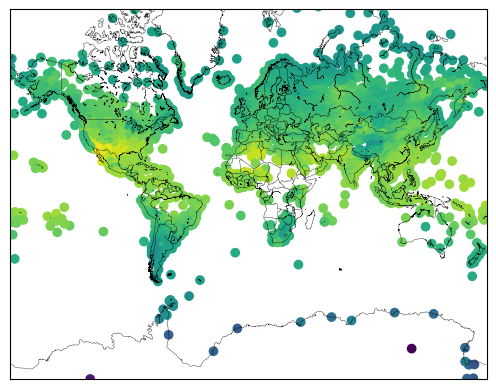

In [10]:
# First, just plot the station data so we can see where our data subset is

map = Basemap(projection='merc',llcrnrlat=-80,urcrnrlat=80,\
            llcrnrlon=-180,urcrnrlon=180,lat_ts=20,resolution='l')
# draw coastlines, country boundaries, fill continents.
map.drawcoastlines(linewidth=0.25)
map.drawcountries(linewidth=0.25)

# # Add station data over the top
x2, y2 = map(points.lon, points.lat)

map.scatter(x2, y2, c=points.temperatures, cmap='viridis')

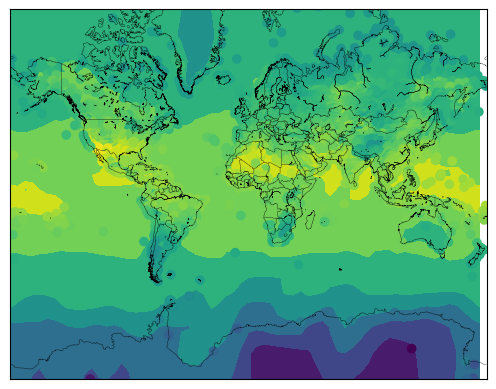

In [11]:
# Then, plot the stations over the gridded data to see the overlay

map = Basemap(projection='merc',llcrnrlat=-80,urcrnrlat=80,\
            llcrnrlon=-180,urcrnrlon=180,lat_ts=20,resolution='l')
# draw coastlines, country boundaries, fill continents.
map.drawcoastlines(linewidth=0.25)
map.drawcountries(linewidth=0.25)

x, y = map(lon, lat)


# # Add station data over the top
x2, y2 = map(points.lon, points.lat)

map.contourf(x, y, data.T, cmap='viridis')

map.scatter(x2, y2, c=points.temperatures, cmap='viridis')